# Task 1: Diagnostic Enhancement of Chest X-Rays

**Scenario:** Raw chest X-rays from the dataset are severely underexposed, hiding lung
structure and potential fluid build-up. This notebook mathematically enhances a sample
X-ray so structures become visible before being handed to diagnostic doctors.

**Pipeline:**
1. Load and display the raw grayscale X-ray
2. Histogram Equalization (contrast enhancement)
3. Color Mapping (COLORMAP_JET false-color heatmap)
4. Color Balance correction
5. Color Filtering / Thresholding (isolate dense tissue)
6. Logarithmic Transformation (expand dark background)
7. Power-Law / Gamma Transformation (fine-tune midtones)


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('output', exist_ok=True)

DATA_PATH = 'data/sample_xray.png'


## 1. Load and Display
Load the raw, underexposed grayscale X-ray straight from the dataset.

Shape: (512, 512) | dtype: uint8
Min / Max / Mean intensity: 2 65 17.75


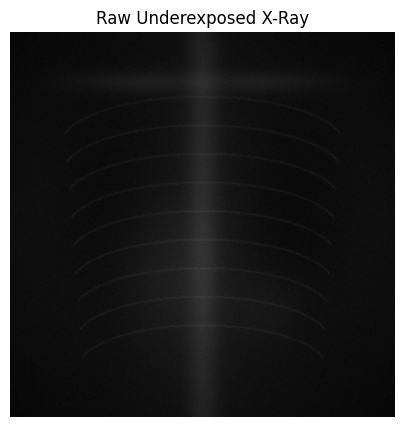

In [2]:
raw = cv2.imread(DATA_PATH, cv2.IMREAD_GRAYSCALE)
if raw is None:
    raise FileNotFoundError(f"Could not load {DATA_PATH} -- check the data/ folder.")

print("Shape:", raw.shape, "| dtype:", raw.dtype)
print("Min / Max / Mean intensity:", raw.min(), raw.max(), round(raw.mean(), 2))

plt.figure(figsize=(5, 5))
plt.imshow(raw, cmap='gray', vmin=0, vmax=255)
plt.title('Raw Underexposed X-Ray')
plt.axis('off')
plt.savefig('output/01_raw_xray.png', bbox_inches='tight', dpi=150)
plt.show()


## 2. Contrast Enhancement — Histogram Equalization
Histogram equalization forcefully redistributes pixel intensities across the full
0-255 range, revealing structures that are otherwise compressed into a narrow band.

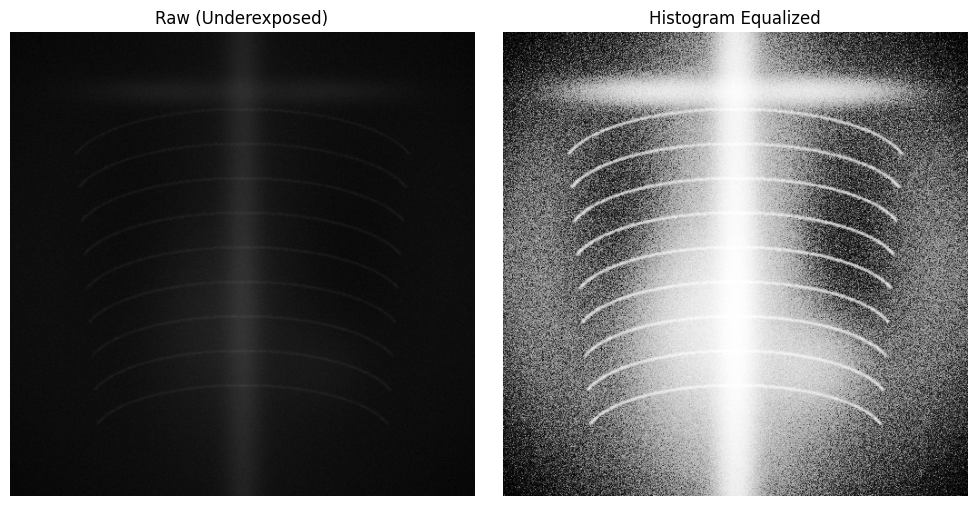

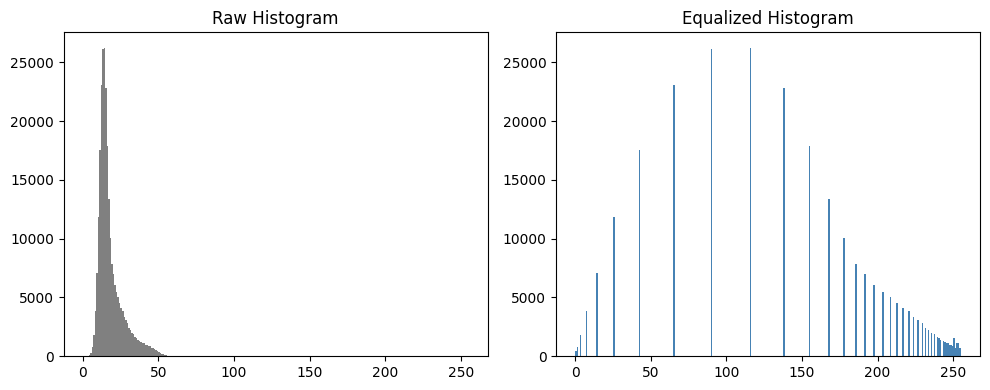

Raw std-dev (contrast): 8.34
Equalized std-dev (contrast): 70.93


In [3]:
equalized = cv2.equalizeHist(raw)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(raw, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Raw (Underexposed)')
axes[0].axis('off')
axes[1].imshow(equalized, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Histogram Equalized')
axes[1].axis('off')
plt.tight_layout()
plt.savefig('output/02_raw_vs_equalized.png', bbox_inches='tight', dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(raw.ravel(), bins=256, range=(0, 255), color='gray')
axes[0].set_title('Raw Histogram')
axes[1].hist(equalized.ravel(), bins=256, range=(0, 255), color='steelblue')
axes[1].set_title('Equalized Histogram')
plt.tight_layout()
plt.savefig('output/02b_histograms.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"Raw std-dev (contrast): {raw.std():.2f}")
print(f"Equalized std-dev (contrast): {equalized.std():.2f}")


**Observation:** the equalized histogram spreads across the full range, and the
lung fields / rib boundaries that were nearly invisible in the raw scan become
clearly visible. The jump in standard deviation quantifies the contrast gain.

## 3. Color Mapping — False-Color Heatmap
Converting the equalized grayscale image into a `COLORMAP_JET` heatmap maps intensity
to a color spectrum, which helps the human eye detect subtle fluid boundaries that are
hard to distinguish in pure grayscale.

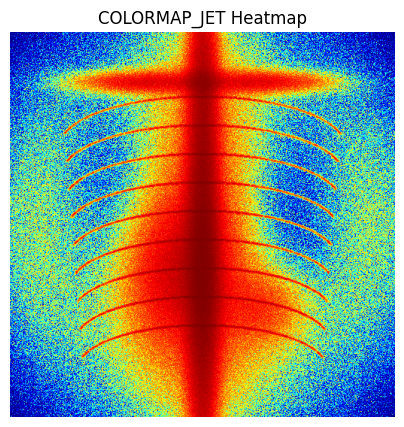

In [4]:
heatmap = cv2.applyColorMap(equalized, cv2.COLORMAP_JET)
heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(heatmap_rgb)
plt.title('COLORMAP_JET Heatmap')
plt.axis('off')
plt.savefig('output/03_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()


## 4. Color Balance
Simulate a lighting correction pass: neutralize any artificial color cast the JET
colormap introduced by scaling each channel so its mean matches the overall gray mean
(a simple gray-world color balance).

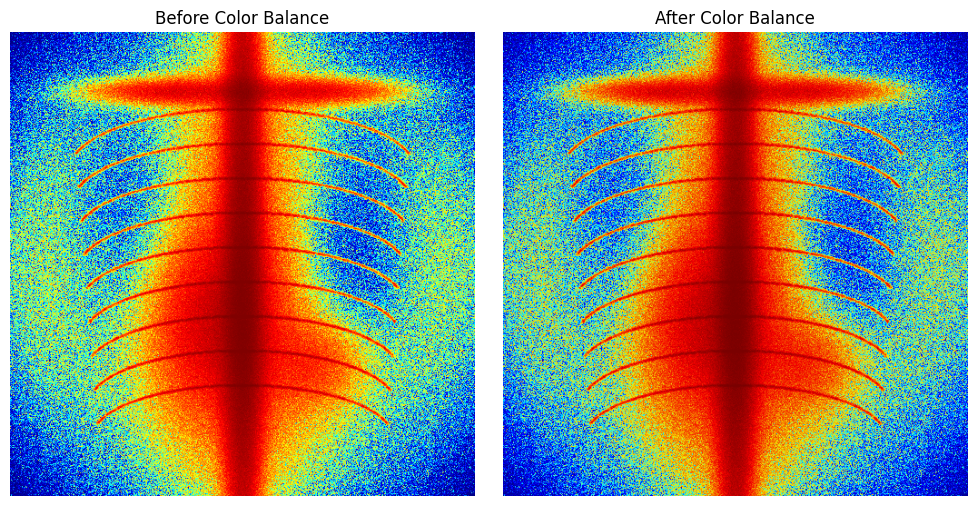

In [5]:
def gray_world_balance(bgr_img):
    img_f = bgr_img.astype(np.float64)
    b, g, r = cv2.split(img_f)
    gray_mean = (b.mean() + g.mean() + r.mean()) / 3.0

    b = np.clip(b * (gray_mean / (b.mean() + 1e-6)), 0, 255)
    g = np.clip(g * (gray_mean / (g.mean() + 1e-6)), 0, 255)
    r = np.clip(r * (gray_mean / (r.mean() + 1e-6)), 0, 255)

    return cv2.merge([b, g, r]).astype(np.uint8)

balanced = gray_world_balance(heatmap)
balanced_rgb = cv2.cvtColor(balanced, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(heatmap_rgb)
axes[0].set_title('Before Color Balance')
axes[0].axis('off')
axes[1].imshow(balanced_rgb)
axes[1].set_title('After Color Balance')
axes[1].axis('off')
plt.tight_layout()
plt.savefig('output/04_color_balance.png', bbox_inches='tight', dpi=150)
plt.show()


## 5. Color Filtering (Thresholding)
Dense tissue (bone, dense fluid) reflects specific high-intensity values. Apply a
strict mathematical threshold on the equalized grayscale matrix to mask out
everything except the densest structures.

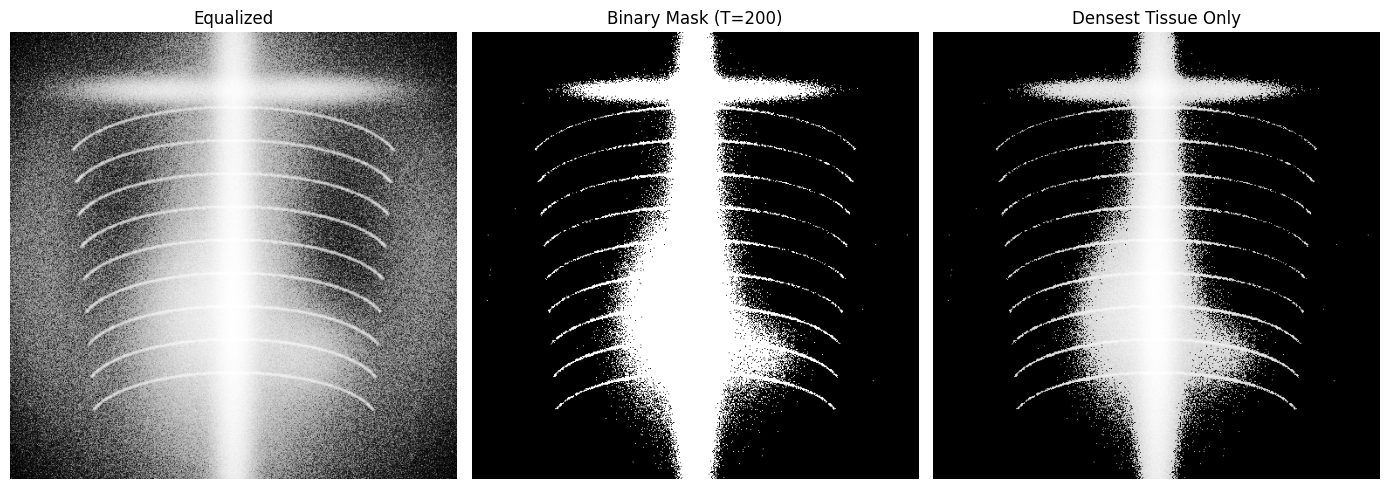

Pixels classified as dense tissue: 22.24% of the image


In [6]:
THRESH_VALUE = 200
_, dense_mask = cv2.threshold(equalized, THRESH_VALUE, 255, cv2.THRESH_BINARY)

dense_only = cv2.bitwise_and(equalized, equalized, mask=dense_mask)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(equalized, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Equalized')
axes[0].axis('off')
axes[1].imshow(dense_mask, cmap='gray')
axes[1].set_title(f'Binary Mask (T={THRESH_VALUE})')
axes[1].axis('off')
axes[2].imshow(dense_only, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Densest Tissue Only')
axes[2].axis('off')
plt.tight_layout()
plt.savefig('output/05_thresholding.png', bbox_inches='tight', dpi=150)
plt.show()

pct_kept = 100 * np.count_nonzero(dense_mask) / dense_mask.size
print(f"Pixels classified as dense tissue: {pct_kept:.2f}% of the image")


## 6. Logarithmic Transformation
Apply a log curve to the **raw** underexposed X-ray to mathematically expand the dark
background regions, revealing the faint outer edges of the ribcage that sit near
black in the original capture.

`s = c * log(1 + r)`

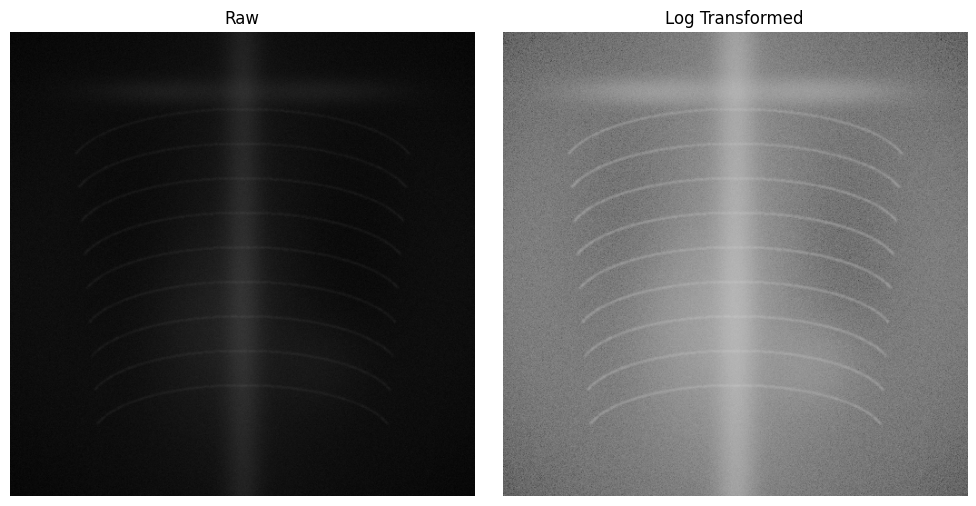

In [7]:
raw_f = raw.astype(np.float64)
c_log = 255 / np.log(1 + 255)
log_transformed = c_log * np.log(1 + raw_f)
log_transformed = np.clip(log_transformed, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(raw, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Raw')
axes[0].axis('off')
axes[1].imshow(log_transformed, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Log Transformed')
axes[1].axis('off')
plt.tight_layout()
plt.savefig('output/06_log_transform.png', bbox_inches='tight', dpi=150)
plt.show()


## 7. Power-Law (Gamma) Transformation
Apply a fractional power-law transform (gamma < 1.0) to fine-tune the midtones —
reducing the harsh contrast of bone so soft lung tissue becomes clearer.

`s = c * r^gamma`

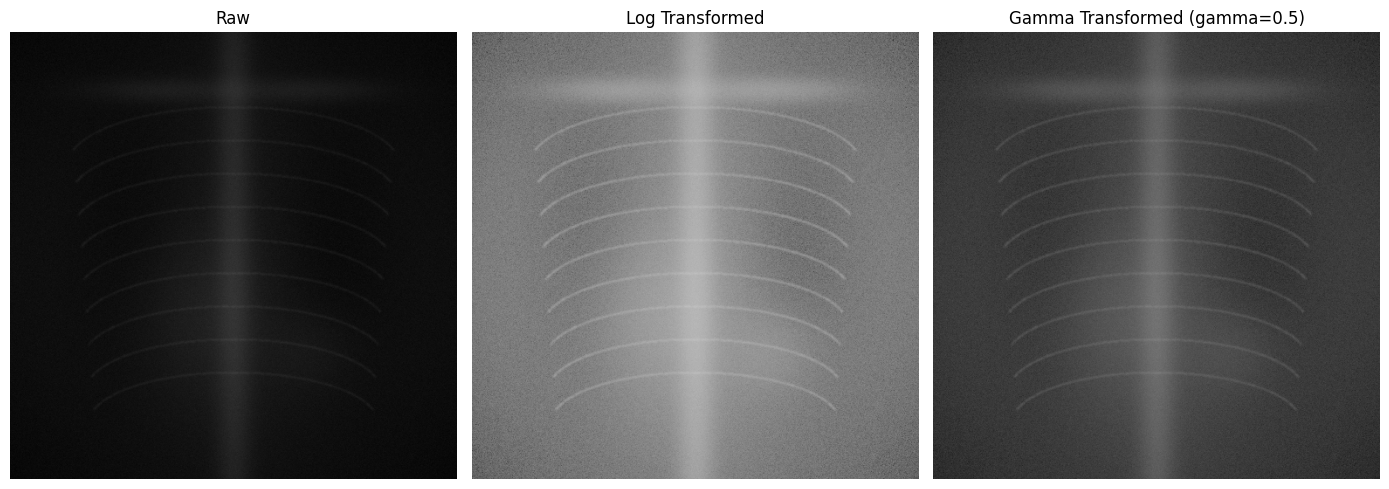

In [8]:
GAMMA = 0.5
raw_norm = raw_f / 255.0
gamma_transformed = np.power(raw_norm, GAMMA) * 255.0
gamma_transformed = np.clip(gamma_transformed, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(raw, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Raw')
axes[0].axis('off')
axes[1].imshow(log_transformed, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Log Transformed')
axes[1].axis('off')
axes[2].imshow(gamma_transformed, cmap='gray', vmin=0, vmax=255)
axes[2].set_title(f'Gamma Transformed (gamma={GAMMA})')
axes[2].axis('off')
plt.tight_layout()
plt.savefig('output/07_gamma_transform.png', bbox_inches='tight', dpi=150)
plt.show()


## Final Summary — Full Pipeline Comparison

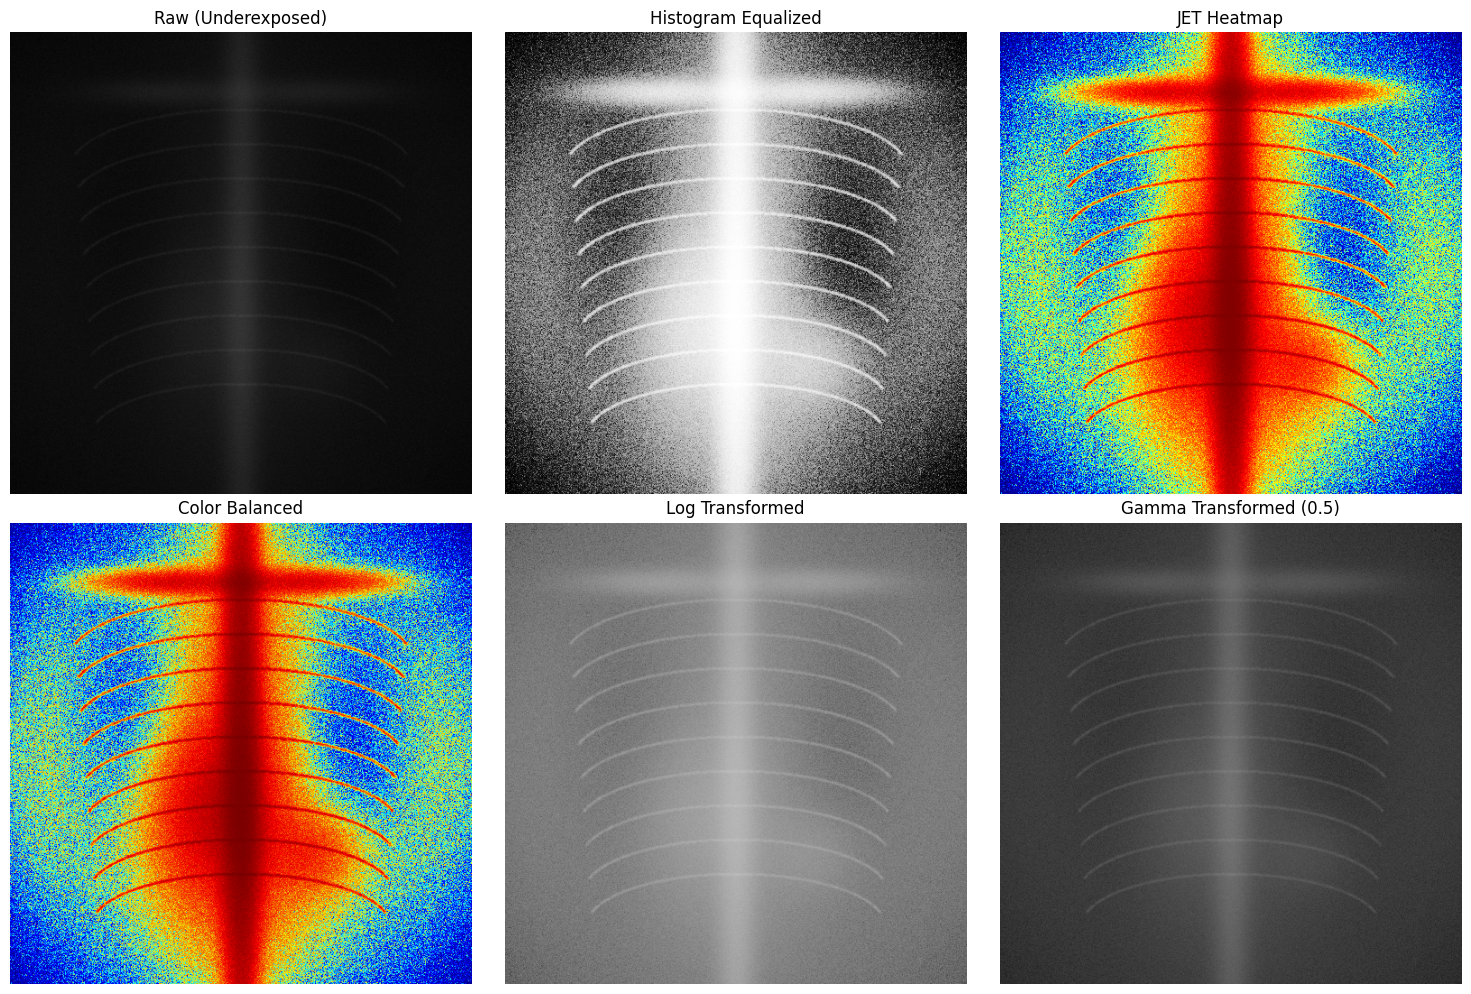

All stage outputs saved to the output/ folder.


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
titles_imgs = [
    ('Raw (Underexposed)', raw, 'gray'),
    ('Histogram Equalized', equalized, 'gray'),
    ('JET Heatmap', heatmap_rgb, None),
    ('Color Balanced', balanced_rgb, None),
    ('Log Transformed', log_transformed, 'gray'),
    (f'Gamma Transformed ({GAMMA})', gamma_transformed, 'gray'),
]
for ax, (title, im, cmap) in zip(axes.ravel(), titles_imgs):
    if cmap:
        ax.imshow(im, cmap=cmap, vmin=0, vmax=255)
    else:
        ax.imshow(im)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.savefig('output/08_full_pipeline_summary.png', bbox_inches='tight', dpi=150)
plt.show()

print("All stage outputs saved to the output/ folder.")
